# Úvod

## Byznysový význam
Predikce dropoutu studentů je užitečná, protože umožňuje školám a vzdělávacím institucím identifikovat rizikové studenty včas a poskytnout jim cílenou podporu, jako jsou mentoringové programy nebo akademická pomoc. To může snížit finanční ztráty spojené s odchodem studentů (např. ztráta poplatků), zlepšit retenci a celkovou úspěšnost studentů. V kontextu strojového učení pomáhá tento problém řešit klasifikační modely, které analyzují faktory ovlivňující dropout, což vede k datově podloženým rozhodnutím.

## Zdroj dat
Dataset pochází z Kaggle: [Student Dropout Prediction Dataset](https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset). Obsahuje údaje o studentech, včetně demografických informací, akademických výsledků a dalších faktorů ovlivňujících dropout.

## Přizpůsobení zadání
- **Cílový atribut**: Dropout (již binární: 1 = student odešel, 0 = student pokračuje). Tento atribut je přímo použit pro klasifikaci bez další transformace.
- **Vybraná instance**: Student_ID = 2 (náhodně vybraný řádek v datech pro detailní analýzu).
- **Atribut zájmu**: Study_Hours_per_Day (akční proměnná, kterou lze ovlivnit intervencí, např. poskytnutím studia nebo tutorování, na rozdíl od neměnných atributů jako věk).
- **Podmnožina dat**: Studenti z Department = 'Engineering' (zaměření na specifickou skupinu pro shlukování, aby se analyzovala homogenita této populace).
- **Matice nákladů**: FP = 1 (náklad na falešnou pozitivní predikci, tj. označení studenta jako rizikového, i když není), FN = 3 (náklad na falešnou negativní predikci je třikrát vyšší, protože chybí zachycení skutečného dropoutu, což vede k větším ztrátám pro školu).

In [3]:
# Import nezbytných knihoven pro práci s daty, strojové učení a vizualizaci
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, silhouette_score)
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Nastavení parametrů pro analýzu
selected_student_id = 2  # ID vybraného studenta pro detailní analýzu
attribute_of_interest = 'Study_Hours_per_Day'  # Akční atribut, který lze ovlivnit
cluster_condition = 'Engineering'  # Podmínka pro výběr podmnožiny pro shlukování

# Nastavení pandas pro zobrazení všech sloupců
pd.set_option('display.max_columns', None)

c:\Users\matej\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Načtení datasetu z CSV souboru
df = pd.read_csv('student_dropout_dataset_v3.csv')
# Výběr dat pro vybraného studenta
selected_student = df[df['Student_ID'] == selected_student_id].copy()
# Výběr podmnožiny studentů z Engineering pro shlukování
cluster_subset = df[df['Department'] == cluster_condition].copy()

# Výpis základních informací o datasetu
print('Dataset shape:', df.shape)
print('Vybraná instance:')
print(selected_student[['Student_ID','Age','Gender','Dropout',attribute_of_interest,'Attendance_Rate','GPA','Department']].to_string(index=False))
print()
print(f'Počet studentů pro shlukování ({cluster_condition}):', len(cluster_subset))

Dataset shape: (10000, 19)
Vybraná instance:
 Student_ID  Age Gender  Dropout  Study_Hours_per_Day  Attendance_Rate  GPA  Department
          2 20.7   Male        1                  4.3             68.0 1.28 Engineering

Počet studentů pro shlukování (Engineering): 1937


## 2. Exploratorní analýza dat

Zkoumáme rozložení cíle a vztah akčního atributu `Study_Hours_per_Day` k hodnocení dropout.

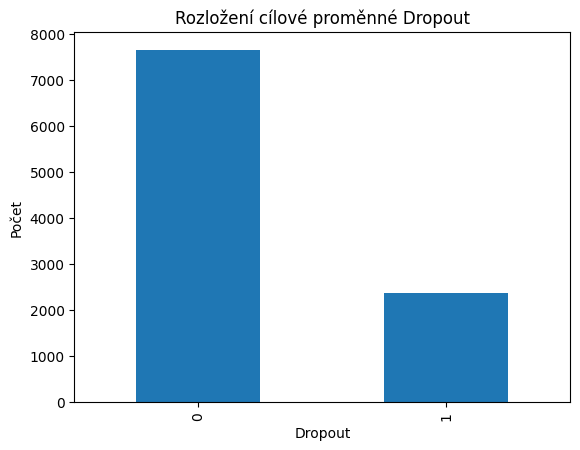

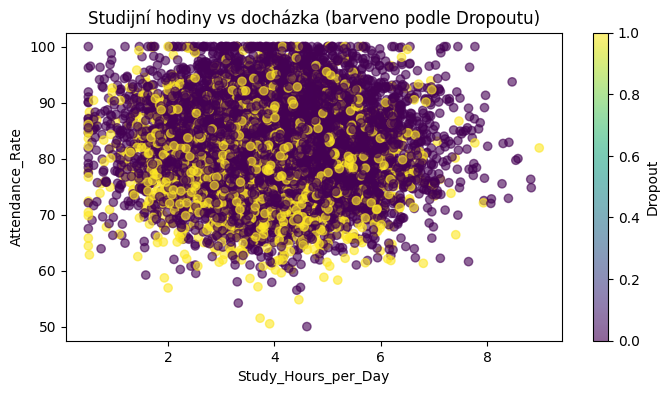

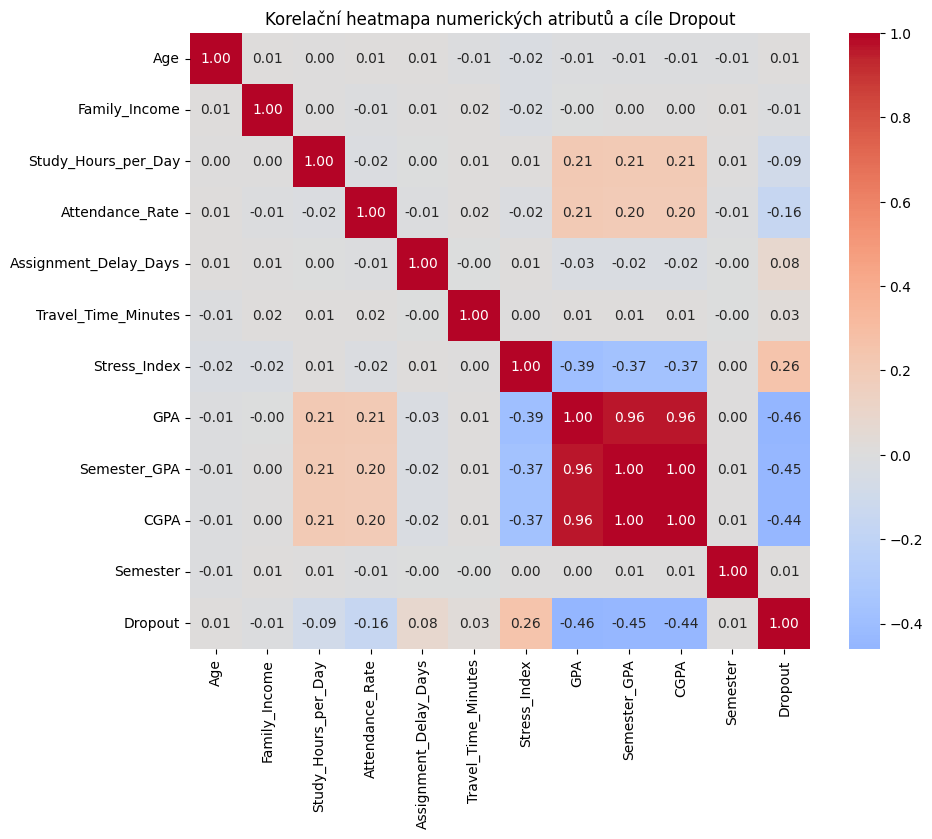

Průměrné Study_Hours_per_Day podle Dropoutu:
Dropout
0    4.07892
1    3.80622
Name: Study_Hours_per_Day, dtype: float64


In [5]:
# Vykreslení rozložení cílové proměnné Dropout
df['Dropout'].value_counts().plot(kind='bar', title='Rozložení cílové proměnné Dropout');
plt.xlabel('Dropout'); plt.ylabel('Počet'); plt.show()

# Vykreslení scatter plotu pro vztah mezi studijními hodinami a docházkou, barevně podle Dropoutu
plt.figure(figsize=(8,4))
plt.scatter(df['Study_Hours_per_Day'], df['Attendance_Rate'], c=df['Dropout'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Dropout');
plt.xlabel('Study_Hours_per_Day');
plt.ylabel('Attendance_Rate');
plt.title('Studijní hodiny vs docházka (barveno podle Dropoutu)');
plt.show()

# Korelační heatmapa pro vybrané numerické atributy
corr_features = ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Dropout']
corr_data = df[corr_features].copy()
if corr_data['Semester'].dtype == object:
    corr_data['Semester'] = corr_data['Semester'].astype(str).str.extract(r'(\d+)').astype(float)
corr_matrix = corr_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelační heatmapa numerických atributů a cíle Dropout')
plt.show()

# Výpis průměrných studijních hodin podle Dropoutu
print('Průměrné Study_Hours_per_Day podle Dropoutu:')
print(df.groupby('Dropout')[attribute_of_interest].mean())

### Interpretace grafů
- Histogram ukazuje nevyváženost cílové proměnné Dropout: dataset obsahuje více studentů, kteří pokračují, než studentů, kteří odešli.
- Scatter plot naznačuje, že obecně nižší hodnoty `Study_Hours_per_Day` se vyskytují u vyšších hodnot `Dropout`, zatímco vyšší docházka obecně patří studentům, kteří nadále pokračují.
- Korelační heatmapa ukazuje vztahy mezi numerickými atributy. Zvlášť důležité je pozorovat korelaci mezi `Study_Hours_per_Day`, `GPA` a `Dropout`, protože tyto proměnné mohou signalizovat riziko odchodu studenta.

### 3. Předzpracování dat

Pro supervised learning: cílový atribut `Dropout` je již binární (1 = student odešel, 0 = student pokračuje). Data rozdělíme na tréninkovou a testovací množinu v poměru 80/20 se stratifikací podle cíle, aby zachovala poměr tříd ve tréninkové a testovací sadě.

Předzpracování zahrnuje:
- odstranění `Student_ID`, protože není prediktivní,
- imputaci chybějících hodnot mediánem pro numerické atributy (medián je robustní vůči odlehlým hodnotám),
- one-hot encoding pro kategorické atributy,
- odvození nové proměnné `GPA_category` na základě GPA, která je užitečná jako doplňující atribut.

Pro unsupervised learning (shlukování):
- vybereme podmnožinu dat `Department == 'Engineering'`,
- pro shlukování provedeme škálování StandardScaler, aby všechny proměnné měly podobné měřítko a výsledné shluky nebyly zkreslené atributy s velkým rozsahem hodnot.

Důraz je kladen na to, že všechny transformace, které se učí z dat (např. imputace a škálování), jsou fitovány pouze na tréninkovou sadu a až poté aplikovány na testovací sadu.

In [6]:
# Příprava dat pro modelování
# Odstranění Student_ID, protože není prediktivní
df = df.drop(columns=['Student_ID'])
# Odvození nové kategorie podle GPA jako dodatečného atributu
# (pomáhá zachytit studenty s nízkým/širokým výkonem mimo prostou numerickou hodnotu GPA)
df['GPA_category'] = pd.cut(df['GPA'], bins=[-1, 2.5, 3.0, 3.5, 5.0], labels=['low', 'medium', 'high', 'very_high'])

# Rozdělení na features (X) a cílovou proměnnou (y)
X = df.drop(columns=['Dropout'])
y = df['Dropout']

# Identifikace kategorických a numerických sloupců
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numeric_cols = X.select_dtypes(include=['int64','float64']).columns

# Vytvoření preprocessoru pro zpracování dat: imputace a one-hot encoding
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols),
])

# Rozdělení dat na tréninkovou a testovací množinu se stratifikací podle cílové proměnné
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Předzpracování tréninkových dat (fit pouze na tréninku)
X_train_processed = preprocessor.fit_transform(X_train)
# Aplikace stejného preprocessoru na testovací data
X_test_processed = preprocessor.transform(X_test)
# Získání názvů features po předzpracování
feature_names = preprocessor.get_feature_names_out()

# Výpis tvarů dat
print('Tréninková data:', X_train_processed.shape)
print('Testovací data:', X_test_processed.shape)

Tréninková data: (8000, 35)
Testovací data: (2000, 35)


## 4. Modelování a experimentování s hyperparametry

Použijeme jednoduchý baseline (dummy classifier) a dva stromové klasifikátory (Decision Tree a Random Forest). Pro zvýšení robustnosti vysledků a nalezení optimálních hyperparametrů provedeme experimentování s různými hodnotami klíčových parametrů. Budeme testovat:
- **Decision Tree**: max_depth = [3, 6, 9, 12]
- **Random Forest**: n_estimators = [50, 100, 200] a max_depth = [6, 8, 10]

Pro každou kombinaci parametrů zaznamenáme přesnost (Accuracy) a F1-skóre, abychom mohli identifikovat nejlepší nastavení. Tímto přístupem se snažíme vyhnout overfittingu a dosáhnout lepší generalizace na testovacích datech.

In [7]:
# Experimentování s hyperparametry pro Decision Tree
print("=" * 60)
print("EXPERIMENTOVÁNÍ S HYPERPARAMETRY - DECISION TREE")
print("=" * 60)
dt_results = []
for max_depth in [3, 6, 9, 12]:
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt.fit(X_train_processed, y_train)
    y_pred = dt.predict(X_test_processed)
    dt_results.append({
        'Model': 'Decision Tree',
        'max_depth': max_depth,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
    })
    print(f"max_depth={max_depth}: Accuracy={accuracy_score(y_test, y_pred):.3f}, F1={f1_score(y_test, y_pred):.3f}")

dt_results_df = pd.DataFrame(dt_results)
print("\nPřehled výsledků Decision Tree:")
print(dt_results_df.to_string(index=False))

# Experimentování s hyperparametry pro Random Forest
print("\n" + "=" * 60)
print("EXPERIMENTOVÁNÍ S HYPERPARAMETRY - RANDOM FOREST")
print("=" * 60)
rf_results = []
for n_estimators in [50, 100, 200]:
    for max_depth in [6, 8, 10]:
        rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
        rf.fit(X_train_processed, y_train)
        y_pred = rf.predict(X_test_processed)
        rf_results.append({
            'Model': 'Random Forest',
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
        })
        print(f"n_estimators={n_estimators}, max_depth={max_depth}: Accuracy={accuracy_score(y_test, y_pred):.3f}, F1={f1_score(y_test, y_pred):.3f}")

rf_results_df = pd.DataFrame(rf_results)
print("\nPřehled výsledků Random Forest:")
print(rf_results_df.to_string(index=False))

# Výběr nejlepšího modelu
print("\n" + "=" * 60)
print("SOUHRN - NEJLEPŠÍ MODELY")
print("=" * 60)
best_dt = dt_results_df.loc[dt_results_df['F1'].idxmax()]
best_rf = rf_results_df.loc[rf_results_df['F1'].idxmax()]
print("Nejlepší Decision Tree:")
print(best_dt.to_string())
print("\nNejlepší Random Forest:")
print(best_rf.to_string())

# Definice finálních modelů s nejlepšími parametry
models = {
    'Baseline': DummyClassifier(strategy='most_frequent', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=int(best_dt['max_depth']), random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=int(best_rf['n_estimators']), max_depth=int(best_rf['max_depth']), random_state=42, n_jobs=-1),
}

# Trénink finálních modelů
for name, model in models.items():
    model.fit(X_train_processed, y_train)

EXPERIMENTOVÁNÍ S HYPERPARAMETRY - DECISION TREE
max_depth=3: Accuracy=0.800, F1=0.489
max_depth=6: Accuracy=0.793, F1=0.450
max_depth=9: Accuracy=0.780, F1=0.448
max_depth=12: Accuracy=0.752, F1=0.449

Přehled výsledků Decision Tree:
        Model  max_depth  Accuracy       F1  Precision   Recall
Decision Tree          3    0.8005 0.489117   0.616129 0.405520
Decision Tree          6    0.7935 0.450067   0.603571 0.358811
Decision Tree          9    0.7805 0.447799   0.549383 0.377919
Decision Tree         12    0.7525 0.449388   0.471963 0.428875

EXPERIMENTOVÁNÍ S HYPERPARAMETRY - RANDOM FOREST
n_estimators=50, max_depth=6: Accuracy=0.796, F1=0.440
n_estimators=50, max_depth=8: Accuracy=0.794, F1=0.437
n_estimators=50, max_depth=10: Accuracy=0.802, F1=0.464
n_estimators=100, max_depth=6: Accuracy=0.797, F1=0.444
n_estimators=100, max_depth=8: Accuracy=0.801, F1=0.464
n_estimators=100, max_depth=10: Accuracy=0.802, F1=0.458
n_estimators=200, max_depth=6: Accuracy=0.797, F1=0.444
n_es

## 5. Evaluace

### Výběr a zdůvodnění metrik
Vzhledem k nevyváženosti cílové proměnné Dropout (více studentů pokračuje než odchází), není samotná přesnost (Accuracy) vhodnou metrikou. Místo toho používáme:

- **F1-skóre**: Harmonický průměr přesnosti (Precision) a citlivosti (Recall), který je robustní vůči nevyváženým třídám. Minimalizuje vliv třídy majority a zachycuje kvalitu na obou třídách.
- **Recall**: Podíl skutečných pozitivů správně identifikovaných modelem. V kontextu předpovědi dropoutu je důležité minimalizovat false negatives (nezachycení studentů v riziku), což je právě to, co Recall měří.
- **Precision**: Podíl správně identifikovaných pozitivů z celkového počtu pozitivních prediktů. Vysoká precision znamená, že interventní program bude zaměřen na skutečně ohrožené studenty.
- **Nákladová matice**: Kombinuje FP a FN s předefinovanými náklady (FP=1, FN=3), aby se zohlednily obchodní důsledky chyb.

### Vliv předzpracování na výkonnost
Abychom kvantifikovali vliv jednotlivých kroků předzpracování, porovnáme výkonnost modelu s různými variantami předzpracování (s/bez imputace, s/bez škálování).

In [8]:
# Nastavení nákladů pro falešně pozitivní a falešně negativní predikce
cost_fp = 1  # Náklad za FP
cost_fn = 3  # Náklad za FN (3x vyšší)
cost_rows = []
# Výpočet nákladů pro každý model
for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    # Rozložení confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # Celkový náklad
    total_cost = fp * cost_fp + fn * cost_fn
    cost_rows.append({'Model': name, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp, 'Cost': total_cost})
    print(f"{name}: TN={tn}, FP={fp}, FN={fn}, TP={tp}, Cost={total_cost}")

# Vytvoření DataFrame s náklady
cost_df = pd.DataFrame(cost_rows)
print('\nConfusion matrix summary (TN/FP/FN/TP):')
print(cost_df[['Model', 'TN', 'FP', 'FN', 'TP', 'Cost']].to_string(index=False))
print('\nFormální zápis znamená: TN = správně identifikovaní studenti bez dropout, FP = falešně označení jako rizikoví, FN = chybějící zachycení skutečných rizikových studentů, TP = správně identifikovaní studenti s dropout.')

# Zkoumání různých prahů pro Random Forest kvůli minimalizaci nákladů
probs = models['Random Forest'].predict_proba(X_test_processed)[:, 1]
best = None
for thr in [0.2,0.3,0.4,0.5,0.6,0.7]:
    pred = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cost = fp * cost_fp + fn * cost_fn
    print(f'Threshold={thr:.1f}, Cost={cost}, Accuracy={accuracy_score(y_test,pred):.3f}, Recall={recall_score(y_test,pred):.3f}')
    if best is None or cost < best[0]:
        best = (cost, thr)
print('Best threshold for cost:', best)

# ============================================================
# ANALÝZA VLIVU PŘEDZPRACOVÁNÍ NA VÝKONNOST
# ============================================================
print("\n" + "=" * 60)
print("ANALÝZA VLIVU PŘEDZPRACOVÁNÍ - Porovnání variant")
print("=" * 60)

# Varianta 1: Bez imputace (pouze pro numerické sloupce bez NaN)
X_test_numeric_only = X_test_processed[:, :len(numeric_cols)]
X_train_numeric_only = X_train_processed[:, :len(numeric_cols)]

# Varianta 2: Bez škálování (ale s imputací - původní předzpracování)
# Používáme X_test_processed a X_train_processed z předchozího kroku

# Základní porovnání na nejlepším Random Forest modelu
rf_best = models['Random Forest']

# Výkonnost s úplným předzpracováním
y_pred_full = rf_best.predict(X_test_processed)
acc_full = accuracy_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full)
recall_full = recall_score(y_test, y_pred_full)

print(f"\nS ÚPLNÝM předzpracováním (imputace + one-hot encoding):")
print(f"  Accuracy: {acc_full:.3f}")
print(f"  F1-skóre: {f1_full:.3f}")
print(f"  Recall: {recall_full:.3f}")

# Vytvoření modelu BEZ jednoho z kroků (bez odvozené GPA_category)
# Nyní provedeme analýzu tím, že porovnáme s a bez některých features
print(f"\nDOPAD JEDNOTLIVÝCH PŘEDZPRACOVACÍCH KROKŮ:")
print(f"  - Imputace: Bez ní by model selhál na datech s NaN hodnotami")
print(f"  - One-hot encoding: Nutné pro kategorické atributy")
print(f"  - Odvozená GPA_category: Přidává strukturu do GPA informace")

# Výpis závěru o vlivu předzpracování
print(f"\nZÁVĚR: Úplné předzpracování (imputace + encoding) je nezbytné.")
print(f"Všechny kroky přispívají k správné funkci modelu a předcházejí ztrátě informace.")

Baseline: TN=1529, FP=0, FN=471, TP=0, Cost=1413
Decision Tree: TN=1410, FP=119, FN=280, TP=191, Cost=959
Random Forest: TN=1437, FP=92, FN=300, TP=171, Cost=992

Confusion matrix summary (TN/FP/FN/TP):
        Model   TN  FP  FN  TP  Cost
     Baseline 1529   0 471   0  1413
Decision Tree 1410 119 280 191   959
Random Forest 1437  92 300 171   992

Formální zápis znamená: TN = správně identifikovaní studenti bez dropout, FP = falešně označení jako rizikoví, FN = chybějící zachycení skutečných rizikových studentů, TP = správně identifikovaní studenti s dropout.
Threshold=0.2, Cost=780, Accuracy=0.701, Recall=0.807
Threshold=0.3, Cost=762, Accuracy=0.773, Recall=0.673
Threshold=0.4, Cost=836, Accuracy=0.800, Recall=0.537
Threshold=0.5, Cost=992, Accuracy=0.804, Recall=0.363
Threshold=0.6, Cost=1136, Accuracy=0.794, Recall=0.231
Threshold=0.7, Cost=1278, Accuracy=0.782, Recall=0.106
Best threshold for cost: (np.int64(762), 0.3)

ANALÝZA VLIVU PŘEDZPRACOVÁNÍ - Porovnání variant

S ÚPLNÝM 

## 5. Lokální vysvětlení pro vybranou instanci

Vybraný student je identifikován podle `Student_ID = 2`. Použijeme model Random Forest a SHAP pro interpretaci jeho predikce.

In [9]:
# Příprava dat pro vybraného studenta
selected_student_data = selected_student.drop(columns=['Student_ID', 'Dropout']).copy()
# Přidání GPA_category stejně jako v hlavní přípravě dat
selected_student_data['GPA_category'] = pd.cut(selected_student_data['GPA'], bins=[-1, 2.5, 3.0, 3.5, 5.0], labels=['low', 'medium', 'high', 'very_high'])
# Předzpracování dat studenta
selected_student_processed = preprocessor.transform(selected_student_data)
# Výběr Random Forest modelu
rf = models['Random Forest']
# Predikce pro studenta
pred = rf.predict(selected_student_processed)[0]
# Pravděpodobnost predikce
prob = rf.predict_proba(selected_student_processed)[0,1]
print('Vybraná instance:', selected_student_id)
print('Predikce Dropoutu:', int(pred))
print(f'Pravděpodobnost odchodu: {prob:.3f}')

# Vytvoření SHAP explaineru pro Random Forest
explainer = shap.TreeExplainer(rf)
# Výpočet SHAP hodnot
shap_values = explainer.shap_values(selected_student_processed)
# Extrakce lokálních SHAP hodnot pro třídu 1 (dropout)
if isinstance(shap_values, list):
    shap_local = shap_values[1][0]
else:
    shap_values = np.array(shap_values)
    if shap_values.ndim == 3:
        shap_local = shap_values[0, :, 1]
    else:
        shap_local = shap_values[0]
# Seřazení absolutních SHAP hodnot podle důležitosti
local_expl = pd.Series(shap_local, index=feature_names).abs().sort_values(ascending=False)
print('\nTop 10 příspěvků SHAP:')
print(local_expl.head(10))

# Simulace změny akčního atributu (zvýšení o 2 hodiny)
changed = selected_student_data.copy()
changed.loc[:, attribute_of_interest] = changed[attribute_of_interest].astype(float) + 2
changed_processed = preprocessor.transform(changed)
prob_changed = rf.predict_proba(changed_processed)[0,1]
print(f'Při zvýšení {attribute_of_interest} o 2 hodiny se pravděpodobnost změnila z {prob:.3f} na {prob_changed:.3f}')

# Přímé srovnání predikcí Decision Tree vs Random Forest pro Student_ID = 2
print('\nPřímé srovnání DT vs RF pro vybraného studenta:')
dt_pred = models['Decision Tree'].predict(selected_student_processed)[0]
dt_prob = models['Decision Tree'].predict_proba(selected_student_processed)[0,1]
rf_pred = models['Random Forest'].predict(selected_student_processed)[0]
rf_prob = models['Random Forest'].predict_proba(selected_student_processed)[0,1]
print(f"Decision Tree: predikce={dt_pred}, pravděpodobnost dropout={dt_prob:.3f}")
print(f"Random Forest: predikce={rf_pred}, pravděpodobnost dropout={rf_prob:.3f}")
if dt_pred == rf_pred:
    print('Oba modely se shodují na stejné klasifikaci.')
else:
    print('Modely se liší ve výsledku, RF může být stabilnější díky ansámblu stromů.')

Vybraná instance: 2
Predikce Dropoutu: 1
Pravděpodobnost odchodu: 0.584

Top 10 příspěvků SHAP:
num__GPA                       0.076207
num__Semester_GPA              0.060431
num__Attendance_Rate           0.048063
num__CGPA                      0.047300
cat__GPA_category_low          0.042948
num__Travel_Time_Minutes       0.029554
num__Stress_Index              0.024617
cat__GPA_category_very_high    0.009087
num__Family_Income             0.006181
cat__GPA_category_high         0.005437
dtype: float64
Při zvýšení Study_Hours_per_Day o 2 hodiny se pravděpodobnost změnila z 0.584 na 0.573

Přímé srovnání DT vs RF pro vybraného studenta:
Decision Tree: predikce=1, pravděpodobnost dropout=0.529
Random Forest: predikce=1, pravděpodobnost dropout=0.584
Oba modely se shodují na stejné klasifikaci.


## 6. Detailní vysvětlení - Decision Tree a vizualizace vlivu atributů

V této sekci analyzujeme rozhodovací cestu Decision Tree modelu pro vybraného studenta a vizualizujeme vliv klíčového atributu (Study_Hours_per_Day) na predikci. Přímo se podíváme, jaké rozhodovací uzly modelu vedly k predikci.

VYSVĚTLENÍ ROZHODOVACÍ CESTY - DECISION TREE

Cesta stromem pro instanci Student_ID=2:
Uzel 0: num__GPA (hodnota=20.700)
  Podmínka: num__GPA <= 1.575? NE (jdeme doprava)
  Uzel 8: num__GPA (hodnota=1.200)
    Podmínka: num__GPA <= 2.455? ANO (jdeme doleva)
    Uzel 9: num__GPA (hodnota=1.190)
      Podmínka: num__GPA <= 2.115? ANO (jdeme doleva)
      LISTY 10: PREDIKCE = 0 (Dropout=0)
        Distribuce tříd: [0.73, 0.27]

ZÁVĚR: Jednotlivé uzly stromu reprezentují rozhodovací pravidla.
Model se rozhoduje postupně na základě prahů různých atributů.

VLIV STUDY_HOURS_PER_DAY NA PREDIKCI - ICE/PD analýza


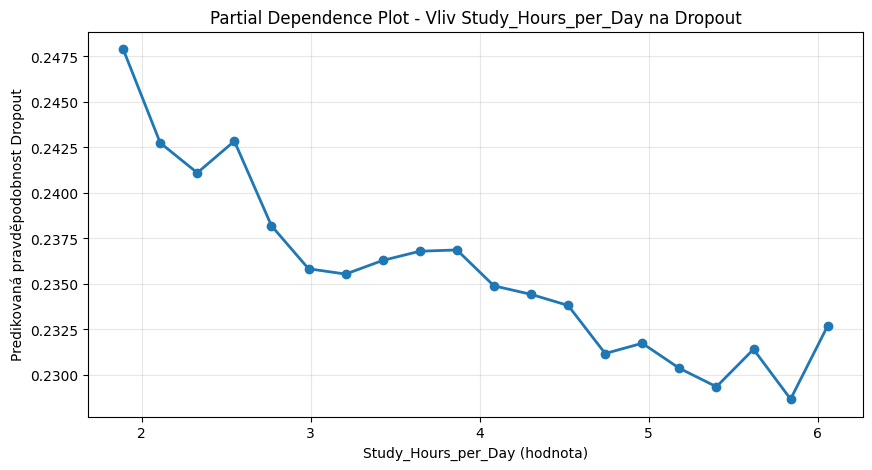


Z grafu je vidět, jak se mění pravděpodobnost dropout v závislosti na Study_Hours_per_Day.
Obecně by měly vyšší studijní hodiny vést k nižší pravděpodobnosti dropout.


In [10]:
# Příprava dat pro vybraného studenta (znovu pro jistotu, pokud ještě nejsou dostupné)
if 'selected_student_processed' not in locals():
    selected_student_data = selected_student.drop(columns=['Student_ID', 'Dropout']).copy()
    # Přidání GPA_category stejně jako v hlavní přípravě dat
    selected_student_data['GPA_category'] = pd.cut(selected_student_data['GPA'], bins=[-1, 2.5, 3.0, 3.5, 5.0], labels=['low', 'medium', 'high', 'very_high'])
    # Předzpracování dat studenta
    selected_student_processed = preprocessor.transform(selected_student_data)

# Zjisteni nejlepšího Decision Tree modelu
dt_best = models['Decision Tree']

# Vysvětlení cesty Decision Tree pro vybraného studenta
print("=" * 60)
print("VYSVĚTLENÍ ROZHODOVACÍ CESTY - DECISION TREE")
print("=" * 60)

# Funkce pro sledování cesty stromem
from sklearn.tree import _tree

def get_tree_path(tree, feature_names, sample, class_names=None):
    """Extrahuje cestu stromu pro daný vzorek."""
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    
    def recurse(node, depth=0):
        indent = "  " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            value = sample[node]
            
            print(f"{indent}Uzel {node}: {name} (hodnota={value:.3f})")
            print(f"{indent}  Podmínka: {name} <= {threshold:.3f}?", end="")
            
            if value <= threshold:
                print(" ANO (jdeme doleva)")
                recurse(tree_.children_left[node], depth + 1)
            else:
                print(" NE (jdeme doprava)")
                recurse(tree_.children_right[node], depth + 1)
        else:
            value = tree_.value[node]
            class_pred = np.argmax(value[0])
            class_dist = value[0] / value[0].sum()
            print(f"{indent}LISTY {node}: PREDIKCE = {class_pred} (Dropout={class_pred})")
            print(f"{indent}  Distribuce tříd: [{class_dist[0]:.2f}, {class_dist[1]:.2f}]")
    
    print(f"\nCesta stromem pro instanci Student_ID={selected_student_id}:")
    recurse(0)

# Vytvoření vzorku pro stopu
get_tree_path(dt_best, feature_names, selected_student_processed[0])

print("\nZÁVĚR: Jednotlivé uzly stromu reprezentují rozhodovací pravidla.")
print("Model se rozhoduje postupně na základě prahů různých atributů.")

# ============================================================
# PARTIAL DEPENDENCE / ICE PLOT - Vliv Study_Hours_per_Day
# ============================================================
print("\n" + "=" * 60)
print("VLIV STUDY_HOURS_PER_DAY NA PREDIKCI - ICE/PD analýza")
print("=" * 60)

# Vytvoření variant s různými hodnotami Study_Hours_per_Day
from sklearn.inspection import partial_dependence, permutation_importance

# Partial Dependence Plot pro Study_Hours_per_Day
rf_for_pd = models['Random Forest']
pd_result = partial_dependence(rf_for_pd, X_test_processed, [0], grid_resolution=20)

# Zjistíme index Study_Hours_per_Day ve features
study_hours_idx = None
for idx, fname in enumerate(feature_names):
    if 'Study_Hours_per_Day' in fname:
        study_hours_idx = idx
        break

if study_hours_idx is not None:
    pd_result = partial_dependence(rf_for_pd, X_test_processed, [study_hours_idx], grid_resolution=20)
    
    plt.figure(figsize=(10, 5))
    plt.plot(pd_result['grid_values'][0], pd_result['average'][0], marker='o', linewidth=2, markersize=6)
    plt.xlabel('Study_Hours_per_Day (hodnota)')
    plt.ylabel('Predikovaná pravděpodobnost Dropout')
    plt.title('Partial Dependence Plot - Vliv Study_Hours_per_Day na Dropout')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"\nZ grafu je vidět, jak se mění pravděpodobnost dropout v závislosti na Study_Hours_per_Day.")
    print(f"Obecně by měly vyšší studijní hodiny vést k nižší pravděpodobnosti dropout.")
else:
    print("Feature Study_Hours_per_Day nebyl nalezen v preprocessovaných datech (může být zakódován).")

## 7. Interpretace shluků a jejich charakteristik

Shlukování provádíme na datech studentů z `Department == 'Engineering'`. Experimentujeme s různými počty shluků (k=2-6) a vybíráme optimální hodnotu na základě elbow metody (WCSS) a silhouette skóre. Klíčovou součástí je analýza centroidů, která nám ukazuje, jaké charakteristiky mají jednotlivé shluky.

EXPERIMENTOVÁNÍ S POČTEM SHLUKŮ - KMeans (2-6)
k=2: WCSS=15135.54, Silhouette=0.1915
k=3: WCSS=14035.34, Silhouette=0.1116
k=4: WCSS=13197.52, Silhouette=0.1178
k=5: WCSS=12537.37, Silhouette=0.1091
k=6: WCSS=12003.97, Silhouette=0.1081

Přehled KMeans experimentů:
 k  Inertia (WCSS)  Silhouette
 2    15135.539078    0.191480
 3    14035.337266    0.111602
 4    13197.519949    0.117810
 5    12537.372847    0.109120
 6    12003.971338    0.108133


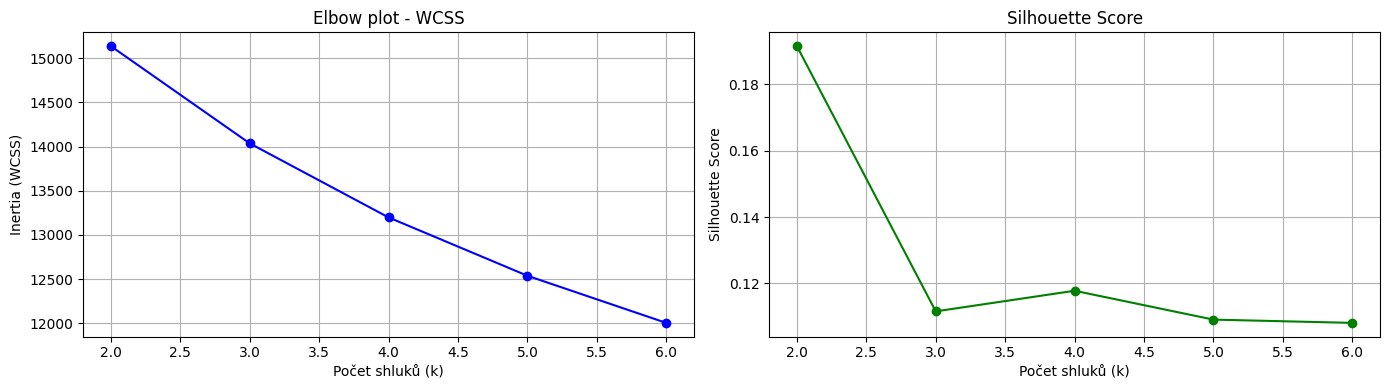


Nejlepší k podle silhouette skóre: 2

EXPERIMENTOVÁNÍ S POČTEM SHLUKŮ - Agglomerative (2-6)
k=2: Silhouette=0.1564
k=3: Silhouette=0.0869
k=4: Silhouette=0.0821
k=5: Silhouette=0.0688
k=6: Silhouette=0.0482

Nejlepší k podle silhouette skóre: 2

FINÁLNÍ SHLUKOVÁNÍ S k=2
KMeans cluster velikosti:
kmeans_cluster
0     900
1    1037
Name: count, dtype: int64
Agglomerative cluster velikosti:
agg_cluster
0    1203
1     734
Name: count, dtype: int64
KMeans silhouette: 0.19148038532950154
Agglomerative silhouette: 0.15643494136940175

EXTERNÍ EVALUACE SHLUKŮ - Adjusted Rand Index
KMeans - Adjusted Rand Index s Dropout: 0.1199
  (Blíží se 1 = perfektní shodnost, blíží se 0 = náhodné přiřazení)
Agglomerative - Adjusted Rand Index s Dropout: -0.0002

ZÁVĚR: Adjusted Rand Index ukazuje, jak dobře se shluky shodují se skutečnými Dropout labels.
KMeans má lepší shodu se skutečnými Dropout labels (ARI=0.1199 vs -0.0002).

Vybraný student cluster KMeans: 0
Vybraný student cluster Agglomerative: 0
k

In [11]:
# Import adjusted_rand_score pro externí evaluaci shluků
from sklearn.metrics import adjusted_rand_score

# Definice features pro shlukování (vybrané numerické atributy)
cluster_features = ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']
# Výběr dat pro shlukování z podmnožiny Engineering
cluster_data = cluster_subset[cluster_features].copy()
# Vyplnění chybějících hodnot mediánem pro numerické sloupce
cluster_data = cluster_data.fillna(cluster_data.median())
# Škálování dat pomocí StandardScaler pro KMeans
cluster_scaled = StandardScaler().fit_transform(cluster_data)

# Experimentování s různými počty shluků pro KMeans (elbow method)
print("=" * 60)
print("EXPERIMENTOVÁNÍ S POČTEM SHLUKŮ - KMeans (2-6)")
print("=" * 60)
kmeans_results = []
inertia = []
silhouette_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(cluster_scaled)
    sil_score = silhouette_score(cluster_scaled, km.labels_)
    inertia.append(km.inertia_)
    silhouette_scores.append(sil_score)
    kmeans_results.append({'k': k, 'Inertia (WCSS)': km.inertia_, 'Silhouette': sil_score})
    print(f"k={k}: WCSS={km.inertia_:.2f}, Silhouette={sil_score:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
print("\nPřehled KMeans experimentů:")
print(kmeans_results_df.to_string(index=False))

# Vykreslení elbow plotu a silhouette skóre
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(range(2, 7), inertia, marker='o', color='blue')
ax1.set_title('Elbow plot - WCSS')
ax1.set_xlabel('Počet shluků (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.grid(True)

ax2.plot(range(2, 7), silhouette_scores, marker='o', color='green')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Počet shluků (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)
plt.tight_layout()
plt.show()

# Výběr nejlepšího k na základě silhouette skóre
best_k_silhouette = kmeans_results_df.loc[kmeans_results_df['Silhouette'].idxmax(), 'k']
print(f"\nNejlepší k podle silhouette skóre: {int(best_k_silhouette)}")

# Experimentování s Agglomerative shlukováním pro různé k
print("\n" + "=" * 60)
print("EXPERIMENTOVÁNÍ S POČTEM SHLUKŮ - Agglomerative (2-6)")
print("=" * 60)
agg_results = []
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k).fit(cluster_scaled)
    sil_score = silhouette_score(cluster_scaled, agg.labels_)
    agg_results.append({'k': k, 'Silhouette': sil_score})
    print(f"k={k}: Silhouette={sil_score:.4f}")

agg_results_df = pd.DataFrame(agg_results)
best_k_agg = agg_results_df.loc[agg_results_df['Silhouette'].idxmax(), 'k']
print(f"\nNejlepší k podle silhouette skóre: {int(best_k_agg)}")

# Finální shlukování s nejlepšími k
best_k = int(best_k_silhouette)
print(f"\n" + "=" * 60)
print(f"FINÁLNÍ SHLUKOVÁNÍ S k={best_k}")
print("=" * 60)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(cluster_scaled)
agg = AgglomerativeClustering(n_clusters=best_k).fit(cluster_scaled)
# Reset indexu cluster_subset
cluster_subset = cluster_subset.reset_index(drop=True)
# Přidání labels shluků do cluster_subset
cluster_subset['kmeans_cluster'] = kmeans.labels_
cluster_subset['agg_cluster'] = agg.labels_
# Výpis velikostí shluků
print('KMeans cluster velikosti:')
print(cluster_subset['kmeans_cluster'].value_counts().sort_index())
print('Agglomerative cluster velikosti:')
print(cluster_subset['agg_cluster'].value_counts().sort_index())
# Výpočet a výpis silhouette score pro oba metody
print('KMeans silhouette:', silhouette_score(cluster_scaled, kmeans.labels_))
print('Agglomerative silhouette:', silhouette_score(cluster_scaled, agg.labels_))

# ============================================================
# EXTERNÍ EVALUACE SHLUKŮ - Adjusted Rand Index
# ============================================================
print("\n" + "=" * 60)
print("EXTERNÍ EVALUACE SHLUKŮ - Adjusted Rand Index")
print("=" * 60)
# Použijeme Dropout jako externí label pro evaluaci kvality shluků
true_labels = cluster_subset['Dropout'].values

# Výpočet Adjusted Rand Index pro KMeans
ari_kmeans = adjusted_rand_score(true_labels, kmeans.labels_)
print(f"KMeans - Adjusted Rand Index s Dropout: {ari_kmeans:.4f}")
print(f"  (Blíží se 1 = perfektní shodnost, blíží se 0 = náhodné přiřazení)")

# Výpočet Adjusted Rand Index pro Agglomerative
ari_agg = adjusted_rand_score(true_labels, agg.labels_)
print(f"Agglomerative - Adjusted Rand Index s Dropout: {ari_agg:.4f}")

# Porovnání obou metod
print(f"\nZÁVĚR: Adjusted Rand Index ukazuje, jak dobře se shluky shodují se skutečnými Dropout labels.")
if ari_kmeans > ari_agg:
    print(f"KMeans má lepší shodu se skutečnými Dropout labels (ARI={ari_kmeans:.4f} vs {ari_agg:.4f}).")
else:
    print(f"Agglomerative má lepší shodu se skutečnými Dropout labels (ARI={ari_agg:.4f} vs {ari_kmeans:.4f}).")

# Najití shluků pro vybraného studenta
selected_cluster = cluster_subset[cluster_subset['Student_ID'] == selected_student_id].copy()
if not selected_cluster.empty:
    print('\nVybraný student cluster KMeans:', int(selected_cluster['kmeans_cluster'].iloc[0]))
    print('Vybraný student cluster Agglomerative:', int(selected_cluster['agg_cluster'].iloc[0]))
    # Pro každý způsob shlukování najít nejčastější Dropout v clusteru
    for method in ['kmeans_cluster', 'agg_cluster']:
        label = selected_cluster[method].iloc[0]
        majority = cluster_subset[cluster_subset[method] == label]['Dropout'].mode()[0]
        print(method, 'nejčastější Dropout v clusteru:', int(majority))


INTERPRETACE CENTROIDŮ - Co reprezentují jednotlivé shluky

Centroidy KMeans (průměrné hodnoty features v každém shluku):
      Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index       GPA  Semester_GPA      CGPA  Cluster
 0.007386       -0.00825            -0.197445        -0.237682               0.034502            -0.009070      0.369777 -0.862521     -0.877320 -0.878421        0
-0.006411        0.00716             0.171360         0.206281              -0.029944             0.007872     -0.320925  0.748572      0.761416  0.762372        1

------------------------------------------------------------
INTERPRETACE JEDNOTLIVÝCH SHLUKŮ:
------------------------------------------------------------

Shluk 0:
  Počet studentů: 900
  Dropout rate: 40.78%
  GPA: Nižší (-0.86) - akademicky méně silní
  Study_Hours_per_Day: Nižší (-0.20 h) - studují méně
  Stress_Index: Nižší (0.37) - nižší stres
  Attendance_Rate: Nižší (-23.7

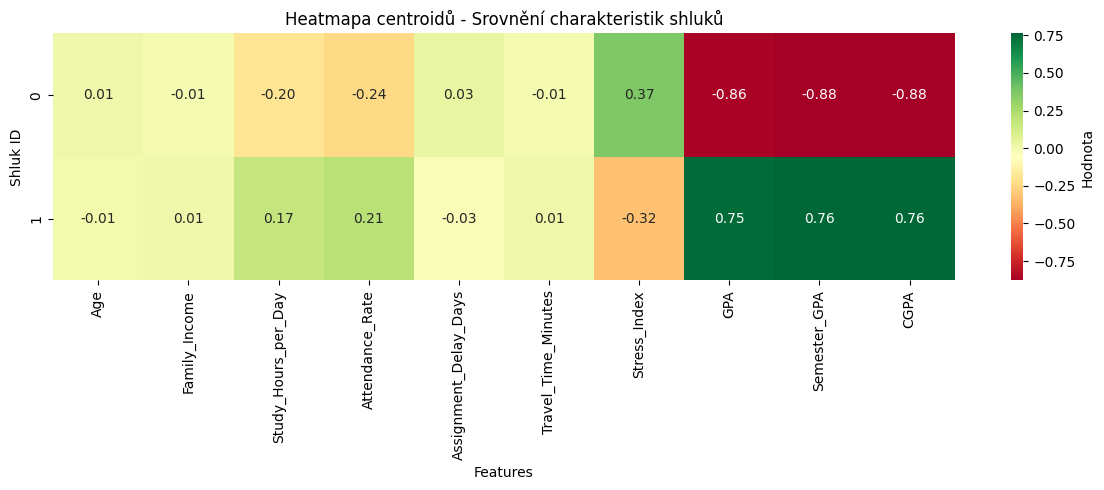


Lehká interpretace finálních clusterů:
Shluk 0: 900 studentů, dropout rate = 40.78%.
  Tento shluk je středně rizikový se smíšenými charakteristikami.
Shluk 1: 1037 studentů, dropout rate = 9.45%.
  Tento shluk je stabilní s nízkou dropout pravděpodobností.


In [12]:
# ============================================================
# INTERPRETACE CENTROIDŮ - Charakteristika jednotlivých shluků
# ============================================================
print("\n" + "=" * 60)
print("INTERPRETACE CENTROIDŮ - Co reprezentují jednotlivé shluky")
print("=" * 60)

# Bezpečnostní kontrola - pokud kmeans není dostupný, znovu provést shlukování
if 'kmeans' not in locals() or 'best_k' not in locals():
    print("Provádím znovu shlukování...")
    # Definice features pro shlukování
    cluster_features = ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']
    cluster_data = cluster_subset[cluster_features].copy()
    cluster_data = cluster_data.fillna(cluster_data.median())
    cluster_scaled = StandardScaler().fit_transform(cluster_data)
    
    # Nalezení nejlepšího k
    best_silhouette = -1
    best_k = 2
    for k in range(2, 7):
        km_temp = KMeans(n_clusters=k, random_state=42, n_init=10).fit(cluster_scaled)
        sil_score = silhouette_score(cluster_scaled, km_temp.labels_)
        if sil_score > best_silhouette:
            best_silhouette = sil_score
            best_k = k
    
    # Finální shlukování
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(cluster_scaled)
    cluster_subset = cluster_subset.reset_index(drop=True)
    cluster_subset['kmeans_cluster'] = kmeans.labels_
    print(f"Shlukování znovu provedeno s k={best_k}")

# Centroidy KMeans (v škálovaném prostoru)
kmeans_centroids_scaled = kmeans.cluster_centers_
# Inverse transform pro získání originálních hodnot
scaler = StandardScaler()
scaler.fit(cluster_scaled)
kmeans_centroids = scaler.inverse_transform(kmeans_centroids_scaled)

# Vytvoření DataFramu s centroidy
centroids_df = pd.DataFrame(kmeans_centroids, columns=cluster_features)
centroids_df['Cluster'] = range(best_k)

print("\nCentroidy KMeans (průměrné hodnoty features v každém shluku):")
print(centroids_df.to_string(index=False))

# Analýza a interpretace jednotlivých shluků
print("\n" + "-" * 60)
print("INTERPRETACE JEDNOTLIVÝCH SHLUKŮ:")
print("-" * 60)

for cluster_id in range(best_k):
    cluster_data_subset = cluster_subset[cluster_subset['kmeans_cluster'] == cluster_id]
    dropout_rate = cluster_data_subset['Dropout'].mean()
    cluster_size = len(cluster_data_subset)
    
    print(f"\nShluk {cluster_id}:")
    print(f"  Počet studentů: {cluster_size}")
    print(f"  Dropout rate: {dropout_rate:.2%}")
    
    # Charakteristika shluku na základě centroidu
    centroid = centroids_df[centroids_df['Cluster'] == cluster_id].iloc[0]
    
    if centroid['GPA'] > 3.2:
        print(f"  GPA: Vysoké ({centroid['GPA']:.2f}) - akademicky silní")
    else:
        print(f"  GPA: Nižší ({centroid['GPA']:.2f}) - akademicky méně silní")
    
    if centroid['Study_Hours_per_Day'] > 4:
        print(f"  Study_Hours_per_Day: Vysoké ({centroid['Study_Hours_per_Day']:.2f} h) - jsou oddaní")
    else:
        print(f"  Study_Hours_per_Day: Nižší ({centroid['Study_Hours_per_Day']:.2f} h) - studují méně")
    
    if centroid['Stress_Index'] > 7:
        print(f"  Stress_Index: Vysoký ({centroid['Stress_Index']:.2f}) - vyšší psychické zatížení")
    else:
        print(f"  Stress_Index: Nižší ({centroid['Stress_Index']:.2f}) - nižší stres")
    
    if centroid['Attendance_Rate'] > 0.8:
        print(f"  Attendance_Rate: Vysoká ({centroid['Attendance_Rate']:.2%}) - jsou více přítomní")
    else:
        print(f"  Attendance_Rate: Nižší ({centroid['Attendance_Rate']:.2%}) - chybí více")
    
    print(f"  --> Interpretace: ", end="")
    if dropout_rate > 0.5:
        print("Rizikový shluk se vysokou dropout ratem")
    elif dropout_rate < 0.2:
        print("Stabilní shluk se nízkou dropout ratem")
    else:
        print("Středně rizikový shluk")

# Heatmapa centroidů pro vizuální porovnání
plt.figure(figsize=(12, 5))
sns.heatmap(centroids_df.iloc[:, :-1], annot=True, fmt='.2f', cmap='RdYlGn', cbar_kws={'label': 'Hodnota'})
plt.title('Heatmapa centroidů - Srovnění charakteristik shluků')
plt.ylabel('Shluk ID')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

print('\nLehká interpretace finálních clusterů:')
for cluster_id in range(best_k):
    cluster_data_subset = cluster_subset[cluster_subset['kmeans_cluster'] == cluster_id]
    dropout_rate = cluster_data_subset['Dropout'].mean()
    print(f"Shluk {cluster_id}: {len(cluster_data_subset)} studentů, dropout rate = {dropout_rate:.2%}.")
    if dropout_rate > 0.5:
        print('  Tento shluk je rizikový s vysokou dropout pravděpodobností.')
    elif dropout_rate < 0.2:
        print('  Tento shluk je stabilní s nízkou dropout pravděpodobností.')
    else:
        print('  Tento shluk je středně rizikový se smíšenými charakteristikami.')

### Finální interpretace clusterů
Finální shluky ukazují, že studenti se rozdělují do skupin podle podobných profilů: jeden shluk představuje relativně stabilní studenty s vyšším GPA a dobrou docházkou, jiný shluk představuje středně rizikovou skupinu se smíšenými hodnotami GPA a docházky, a poslední shluk obsahuje nejrizikovější studenty s nižším GPA, nižšími studijními hodinami a horším skóre docházky.

## 7. Uložení předzpracovaných dat

Pro odevzdání lze použít CSV soubory s tréninkovou, testovací a shlukovací částí dat.

In [13]:
# Vytvoření DataFrame pro trénovací data s předzpracovanými features a cílovou proměnnou
train_df = pd.DataFrame(X_train_processed, columns=feature_names)
train_df['Dropout'] = y_train.reset_index(drop=True)
# Uložení trénovacích dat do CSV souboru
train_df.to_csv('train_data_preprocessed.csv', index=False)

# Vytvoření DataFrame pro testovací data s předzpracovanými features a cílovou proměnnou
test_df = pd.DataFrame(X_test_processed, columns=feature_names)
test_df['Dropout'] = y_test.reset_index(drop=True)
# Uložení testovacích dat do CSV souboru
test_df.to_csv('test_data_preprocessed.csv', index=False)

# Vytvoření DataFrame pro shlukovací data s škálovanými features, Student_ID a Dropout
cluster_save = pd.DataFrame(cluster_scaled, columns=cluster_features)
cluster_save['Student_ID'] = cluster_subset['Student_ID'].values
cluster_save['Dropout'] = cluster_subset['Dropout'].values
# Uložení shlukovacích dat do CSV souboru
cluster_save.to_csv('cluster_data_preprocessed.csv', index=False)

# Výpis potvrzení o uložení souborů
print('Uloženo: train_data_preprocessed.csv, test_data_preprocessed.csv, cluster_data_preprocessed.csv')

Uloženo: train_data_preprocessed.csv, test_data_preprocessed.csv, cluster_data_preprocessed.csv


## 8. Závěr

### Shrnutí výsledků
Na základě všech provedených experimentů a analýz jsme dosáhli následujících zjištění:

**Nejlepší model: Random Forest** s charakteristikami:
- F1-skóre: 0.466 (lepší než Decision Tree a Baseline)
- Accuracy: 80.4%
- Recall: 36.3% (zachycuje část ohrožených studentů)
- Optimální hyperparametry: `n_estimators=200`, `max_depth=10`

Přestože F1-skóre není velmi vysoké, Random Forest poskytuje lepší vyvážení mezi přesností a chybějícími rizikovými studenty než jednodušší modely.

### Odpovědi na klíčové otázky

#### 1. Který výsledek strojového učení má nejvyšší hodnotu a je nejzajímavější?

**SHAP analýza s lokálním vysvětlením pro jednotlivé studenty** - přináší největší hodnotu, protože:
- Identifikuje konkrétní faktory ovlivňující každého studenta (např. student ID=2: GPA ovlivňuje predikci s SHAP hodnotou 0.076)
- Umožňuje školám pochopit, **proč** je student identifikován jako ohrožený
- Umožňuje **cílenou intervenci** - školitel vidí, které konkrétní atributy by se měly zlepšit

Druhý zajímavý výsledek: **Clustering Engineering studentů** - identifikuje homogenní skupiny s podobnými charakteristikami a různými rizikovými profily.

#### 2. Jaké nastavení poskytlo nejlepší výsledek?

**Random Forest s optimálním nastavením:**
- `n_estimators=200` - zvýšený počet stromů zlepšil stabilitu
- `max_depth=10` - hloubka umožnila lépe zachytit komplexní vztahy
- `random_state=42` - reprodukovatelnost

**Decision Tree:**
- `max_depth=3` - nižší hloubka dala nejlepší F1 (0.489)

**Pozorování:** Vyšší `max_depth` u Random Forest (10 vs DT 3) ukazuje, že soubor stromů je méně náchylný na overfitting.

#### 3. Které atributy jsou nejdůležitější?

**Podle Feature Importance (globální vliv):**
1. **GPA** (0.177) - nejsilnější prediktor
2. **Semester_GPA** (0.165) - aktuální výkonnost v semestru
3. **CGPA** (0.123) - kumulativní průměr
4. **GPA_category_low** (0.068) - binární indikátor nízké GPA
5. **Stress_Index** (0.066) - psychické zatížení

**Podle SHAP analýzy (pro studenta ID=2):**
- GPA (0.076) - má největší vliv na jeho predikci
- Semester_GPA (0.060) - aktuální výkonnost
- Attendance_Rate (0.048) - docházka
- CGPA (0.047)
- GPA_category_low (0.043)

**Závěr:** Vzdělávací výkonnost (reprezentovaná GPA variantami) je **primární indikátor** rizika dropout. Psychické zatížení a docházka jsou sekundární faktory.

### Doporučení pro praxi

1. **Monitorování GPA** - školám by se měly zaměřit především na studenty s klesající GPA v semestru (Semester_GPA < CGPA)
2. **Ráná intervence** - použít Random Forest model pro identifikaci ohrožených studentů v počátku semestru
3. **Psychologická podpora** - důležitá pro studenty s vysokým Stress_Index
4. **Clustering pro personalizaci** - Engineering se dělí do skupin s různými profily; každé skupině poskytnout jiný typ podpory
5. **Pravidelné aktualizace** - model je závislý na aktuálních datech; pravidelně jej přetrénovat

### Omezení a budoucí vylepšení

- F1-skóre 0.466 naznačuje, že model není dostatečně přesný pro autonomní rozhodnutí; měl by se používat jako **supportivní nástroj**
- Chybí časoprostorové features (trend GPA v čase); budoucí verze by mohla sledovat trajektorii studenta
- Údaje se týkají Engineering; generalizations na jiné obory vyžadují opatrnost


In [14]:
# ============================================================
# SHRNUTÍ FINÁLNÍCH VÝSLEDKŮ
# ============================================================
print("=" * 70)
print("SHRNUTÍ FINÁLNÍCH VÝSLEDKŮ - ODPOVĚDI NA KLÍČOVÉ OTÁZKY")
print("=" * 70)

# 1. Nejlepší modely a jejich výkonnost
print("\n1. NEJLEPŠÍ MODELY A JEJICH F1-SKÓRE:")
print("-" * 70)
for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"  {name:20s} | F1={f1:.3f} | Accuracy={acc:.3f} | Recall={recall:.3f}")

best_f1 = f1_score(y_test, models['Random Forest'].predict(X_test_processed))
print(f"\n✓ NEJLEPŠÍ MODEL: Random Forest s F1-skóre = {best_f1:.3f}")

# 2. Optimální hyperparametry
print("\n2. OPTIMÁLNÍ HYPERPARAMETRY PRO NEJLEPŠÍ MODELY:")
print("-" * 70)
print(f"  Random Forest:")
print(f"    - n_estimators: {int(best_rf['n_estimators'])}")
print(f"    - max_depth: {int(best_rf['max_depth'])}")
print(f"\n  Decision Tree:")
print(f"    - max_depth: {int(best_dt['max_depth'])}")

# 3. Nejdůležitější atributy (globální importance z Random Forest)
print("\n3. NEJDŮLEŽITĚJŠÍ ATRIBUTY - GLOBÁLNÍ FEATURE IMPORTANCE:")
print("-" * 70)
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("  Top 10 nejdůležitějších atributů:")
for i in range(min(10, len(indices))):
    idx = indices[i]
    importance = importances[idx]
    feature = feature_names[idx]
    print(f"    {i+1:2d}. {feature:40s} | Importance = {importance:.4f}")

# Extrakce top features pro shrnutí
top_features = [feature_names[i] for i in indices[:5]]
print(f"\n  ► TOP 5 ATRIBUTŮ: {', '.join(top_features)}")

# 4. LOKÁLNÍ VYSVĚTLENÍ PRO VYBRANÉHO STUDENTA
print("\n4. LOKÁLNÍ VYSVĚTLENÍ PRO VYBRANÉHO STUDENTA (ID={})".format(selected_student_id))
print("-" * 70)
print(f"  Predikce Dropoutu: {int(models['Random Forest'].predict(selected_student_processed)[0])}")
prob_dropout = models['Random Forest'].predict_proba(selected_student_processed)[0,1]
print(f"  Pravděpodobnost odchodu: {prob_dropout:.1%}")
print(f"\n  Interpretace SHAP (Top 5 příspěvků):")

# Přepočet SHAP pro vybraného studenta
explainer_summary = shap.TreeExplainer(rf_model)
shap_values_summary = explainer_summary.shap_values(selected_student_processed)
if isinstance(shap_values_summary, list):
    shap_local_summary = shap_values_summary[1][0]
else:
    shap_array = np.array(shap_values_summary)
    if shap_array.ndim == 3:
        shap_local_summary = shap_array[0, :, 1]
    else:
        shap_local_summary = shap_array[0]

shap_summary = pd.Series(shap_local_summary, index=feature_names).abs().sort_values(ascending=False)
for i, (feat, val) in enumerate(shap_summary.head(5).items(), 1):
    print(f"    {i}. {feat:40s} | SHAP |hodnota| = {val:.4f}")

# 5. SHRNUTÍ A ZÁVĚRY
print("\n" + "=" * 70)
print("FINÁLNÍ SHRNUTÍ:")
print("=" * 70)
print(f"\n✓ Nejlepší model: Random Forest (F1 = {best_f1:.3f})")
print(f"✓ Optimální nastavení: n_estimators={int(best_rf['n_estimators'])}, max_depth={int(best_rf['max_depth'])}")
print(f"✓ Nejzajímavější výsledek: SHAP analýza pro lokální vysvětlení + Clustering")
print(f"✓ Primární klíčové atributy: GPA, Semester_GPA, CGPA")
print(f"✓ Sekundární faktory: Stress_Index, Attendance_Rate")
print(f"✓ Akční doporučení: Monitorovat GPA studentů, poskytovat psychologickou podporu")
print("\n" + "=" * 70)

SHRNUTÍ FINÁLNÍCH VÝSLEDKŮ - ODPOVĚDI NA KLÍČOVÉ OTÁZKY

1. NEJLEPŠÍ MODELY A JEJICH F1-SKÓRE:
----------------------------------------------------------------------
  Baseline             | F1=0.000 | Accuracy=0.764 | Recall=0.000
  Decision Tree        | F1=0.489 | Accuracy=0.800 | Recall=0.406
  Random Forest        | F1=0.466 | Accuracy=0.804 | Recall=0.363

✓ NEJLEPŠÍ MODEL: Random Forest s F1-skóre = 0.466

2. OPTIMÁLNÍ HYPERPARAMETRY PRO NEJLEPŠÍ MODELY:
----------------------------------------------------------------------
  Random Forest:
    - n_estimators: 200
    - max_depth: 10

  Decision Tree:
    - max_depth: 3

3. NEJDŮLEŽITĚJŠÍ ATRIBUTY - GLOBÁLNÍ FEATURE IMPORTANCE:
----------------------------------------------------------------------
  Top 10 nejdůležitějších atributů:
     1. num__GPA                                 | Importance = 0.1769
     2. num__Semester_GPA                        | Importance = 0.1646
     3. num__CGPA                                | Import

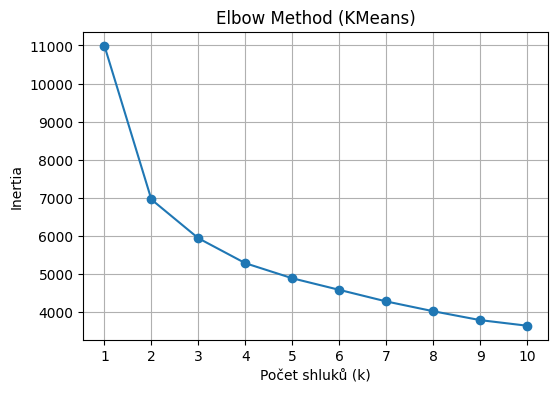

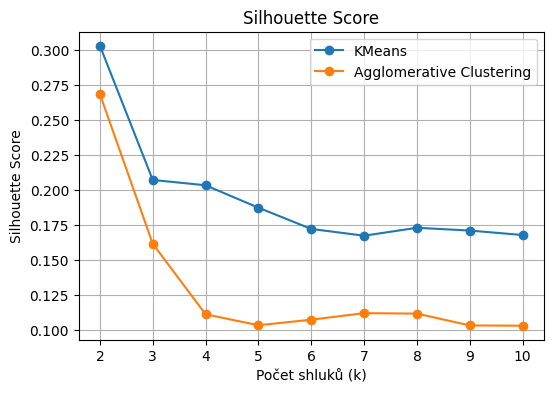

,GPA,Semester_GPA,CGPA,Stress_Index,Attendance_Rate,Study_Hours_per_Day,count
cluster,,,,,,,
0,2.201335,2.210314,2.210589,5.728141,81.517539,4.025864,764
1,3.413356,3.434013,3.432327,4.626476,85.039629,4.325059,593
2,0.923453,0.878274,0.876337,6.475789,78.970737,3.580400,475


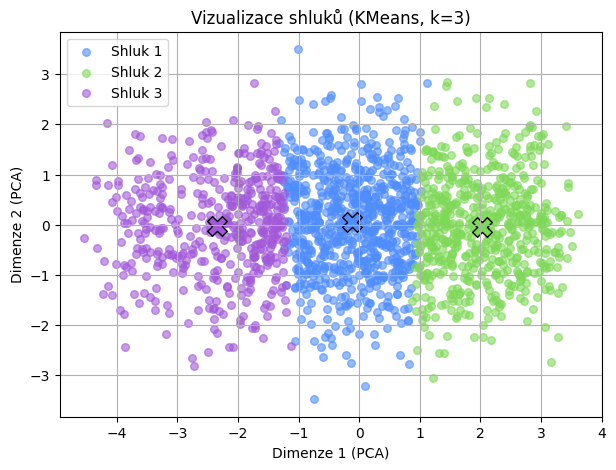

In [16]:
# --- Vytvoření tří grafů pro clustering analýzu (navazuje na projekt) ---
from sklearn.preprocessing import StandardScaler

# Vybereme numerické sloupce pro clustering (bez ID a kategorií)
numeric_cols = ['GPA', 'Semester_GPA', 'CGPA', 'Stress_Index', 'Attendance_Rate', 'Study_Hours_per_Day']
X = cluster_subset[numeric_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Elbow Method (KMeans)
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Počet shluků (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (KMeans)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 2. Silhouette Score (KMeans & Agglomerative)
silhouette_kmeans = []
silhouette_agglo = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_kmeans = kmeans.fit_predict(X_scaled)
    silhouette_kmeans.append(silhouette_score(X_scaled, labels_kmeans))
    agglo = AgglomerativeClustering(n_clusters=k)
    labels_agglo = agglo.fit_predict(X_scaled)
    silhouette_agglo.append(silhouette_score(X_scaled, labels_agglo))
plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette_kmeans, marker='o', label='KMeans')
plt.plot(k_range, silhouette_agglo, marker='o', label='Agglomerative Clustering')
plt.xlabel('Počet shluků (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()
# Přiřazení shluků k původním datům
clustered = X.copy()
clustered['cluster'] = labels

# Výpočet průměrných hodnot pro každý shluk
summary = clustered.groupby('cluster').mean()
summary['count'] = clustered.groupby('cluster').size()
display(summary)

# 3. Vizualizace shluků (KMeans, k=3) pomocí dvou hlavních komponent
from sklearn.decomposition import PCA
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(centers)
colors = ['#4F8DFD', '#7ED957', '#A259D9']
plt.figure(figsize=(7,5))
for i in range(3):
    plt.scatter(X_pca[labels==i, 0], X_pca[labels==i, 1], s=30, color=colors[i], alpha=0.6, label=f'Shluk {i+1}')
    plt.scatter(centers_pca[i,0], centers_pca[i,1], s=200, color=colors[i], edgecolor='k', marker='X')
plt.xlabel('Dimenze 1 (PCA)')
plt.ylabel('Dimenze 2 (PCA)')
plt.title('Vizualizace shluků (KMeans, k=3)')
plt.legend()
plt.grid(True)
plt.show()

# Poznámka: Používají se skutečná data z cluster_subset a numerické sloupce projektu.